In [1]:
import sys
import pandas as pd
import mplsoccer

print("실행 경로:", sys.executable)
print("pandas:", pd.__version__)
print("mplsoccer:", mplsoccer.__version__)
print("✅ 셋업 완료!")

실행 경로: c:\Users\coomi\anaconda3\envs\football\python.exe
pandas: 3.0.2
mplsoccer: 1.6.1
✅ 셋업 완료!


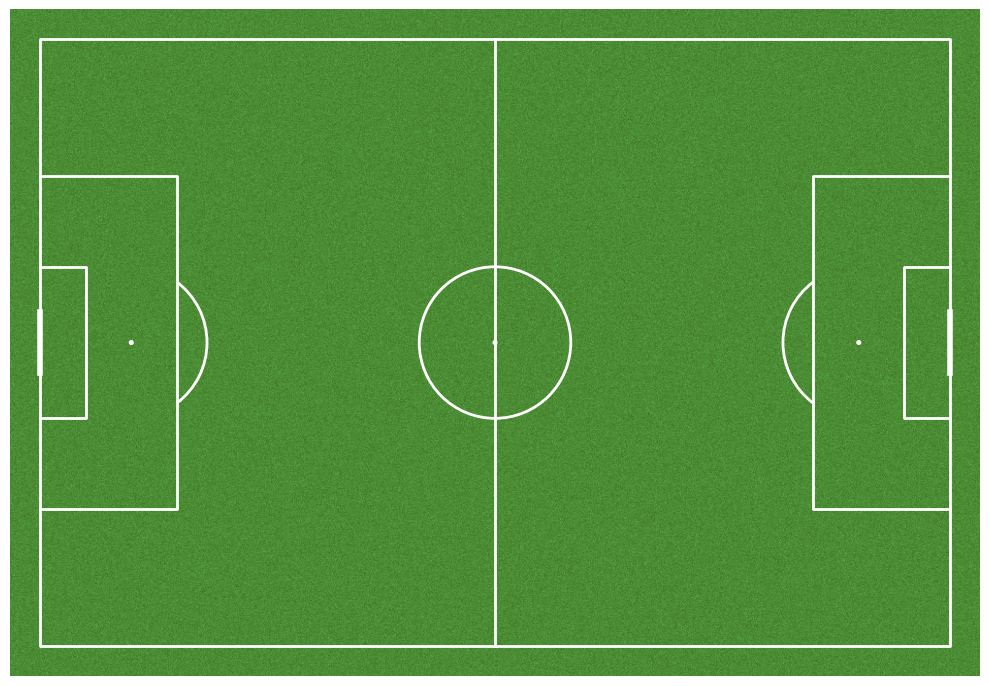

In [2]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))
plt.show()

In [5]:
import pandas as pd
pd.set_option('display.max_rows', None)  # 전체 다 보이게

comp = sb.competitions()

# 'World Cup'이 들어간 대회만 필터링
wc = comp[comp['competition_name'].str.contains('World Cup', case=False)]
print(wc[['competition_id', 'season_id', 'competition_name', 'season_name']].to_string())

    competition_id  season_id    competition_name season_name
29            1470        274  FIFA U20 World Cup        1979
30              43        106      FIFA World Cup        2022
31              43          3      FIFA World Cup        2018
32              43         55      FIFA World Cup        1990
33              43         54      FIFA World Cup        1986
34              43         51      FIFA World Cup        1974
35              43        272      FIFA World Cup        1970
36              43        270      FIFA World Cup        1962
37              43        269      FIFA World Cup        1958
78              72        107   Women's World Cup        2023
79              72         30   Women's World Cup        2019


In [6]:
# 2022 카타르 월드컵 전체 경기 목록
matches = sb.matches(competition_id=43, season_id=106)

# 한국(Korea) 경기만 찾기
korea = matches[
    matches['home_team'].str.contains('Korea', case=False) |
    matches['away_team'].str.contains('Korea', case=False)
]

print(korea[['match_id', 'home_team', 'away_team', 'home_score', 'away_score']].to_string())

    match_id    home_team    away_team  home_score  away_score
35   3857287      Uruguay  South Korea           0           0
48   3869253       Brazil  South Korea           4           1
57   3857299  South Korea        Ghana           2           3
63   3857262  South Korea     Portugal           2           1


In [7]:
match_id = 3857262  # 한국 vs 포르투갈
events = sb.events(match_id=match_id)
shots = events[events['type'] == 'Shot'].copy()
korea_shots = shots[shots['team'] == 'South Korea'].copy()

print("한국 전체 슈팅 수:", len(korea_shots))
print(korea_shots[['minute', 'player', 'shot_outcome']].to_string())

한국 전체 슈팅 수: 12
      minute          player shot_outcome
3207      15   Heung-Min Son      Blocked
3208      16    Gue-Sung Cho        Saved
3209      26  Young-Gwon Kim         Goal
3210      30   In-Beom Hwang      Blocked
3214      39   Heung-Min Son        Saved
3220      55   Heung-Min Son      Blocked
3221      56    Jae-Sung Lee        Off T
3222      65   Heung-Min Son        Saved
3223      66   In-Beom Hwang        Saved
3224      69   Heung-Min Son      Blocked
3226      73     Kang-In Lee        Off T
3229      90  Hee-Chan Hwang         Goal


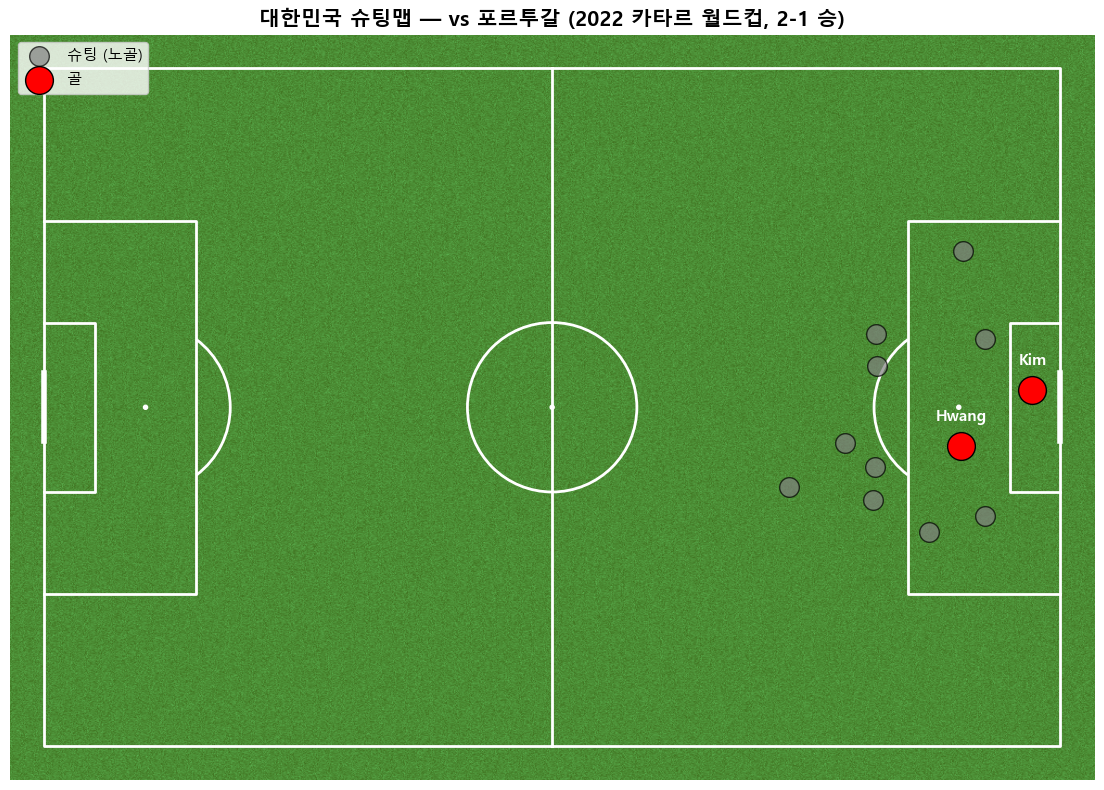

✅ 슈팅맵 완성! korea_portugal_shotmap.png 저장됨


In [8]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# location 컬럼은 [x, y] 리스트 → x, y로 분리
korea_shots['x'] = korea_shots['location'].apply(lambda loc: loc[0])
korea_shots['y'] = korea_shots['location'].apply(lambda loc: loc[1])

# 골 / 노골 분리
goals = korea_shots[korea_shots['shot_outcome'] == 'Goal']
no_goals = korea_shots[korea_shots['shot_outcome'] != 'Goal']

# 축구장 그리기
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# 노골 = 회색, 골 = 빨강
pitch.scatter(no_goals['x'], no_goals['y'], ax=ax,
              color='gray', s=200, alpha=0.7, edgecolors='black', label='슈팅 (노골)')
pitch.scatter(goals['x'], goals['y'], ax=ax,
              color='red', s=400, edgecolors='black', label='골', zorder=5)

# 골 넣은 선수 이름 표시
for _, row in goals.iterrows():
    ax.text(row['x'], row['y'] - 3, row['player'].split()[-1],
            color='white', fontsize=11, ha='center', fontweight='bold')

ax.set_title('대한민국 슈팅맵 — vs 포르투갈 (2022 카타르 월드컵, 2-1 승)',
             fontsize=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)

plt.savefig('korea_portugal_shotmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 슈팅맵 완성! korea_portugal_shotmap.png 저장됨")

In [9]:
# xG 컬럼 확인 (StatsBomb은 'shot_statsbomb_xg'에 저장)
print(korea_shots[['minute', 'player', 'shot_outcome', 'shot_statsbomb_xg']].to_string())
print("\n한국 xG 합계:", round(korea_shots['shot_statsbomb_xg'].sum(), 2))

      minute          player shot_outcome  shot_statsbomb_xg
3207      15   Heung-Min Son      Blocked           0.011032
3208      16    Gue-Sung Cho        Saved           0.040536
3209      26  Young-Gwon Kim         Goal           0.624296
3210      30   In-Beom Hwang      Blocked           0.020656
3214      39   Heung-Min Son        Saved           0.024710
3220      55   Heung-Min Son      Blocked           0.023785
3221      56    Jae-Sung Lee        Off T           0.021393
3222      65   Heung-Min Son        Saved           0.039930
3223      66   In-Beom Hwang        Saved           0.100738
3224      69   Heung-Min Son      Blocked           0.046220
3226      73     Kang-In Lee        Off T           0.023724
3229      90  Hee-Chan Hwang         Goal           0.421961

한국 xG 합계: 1.4


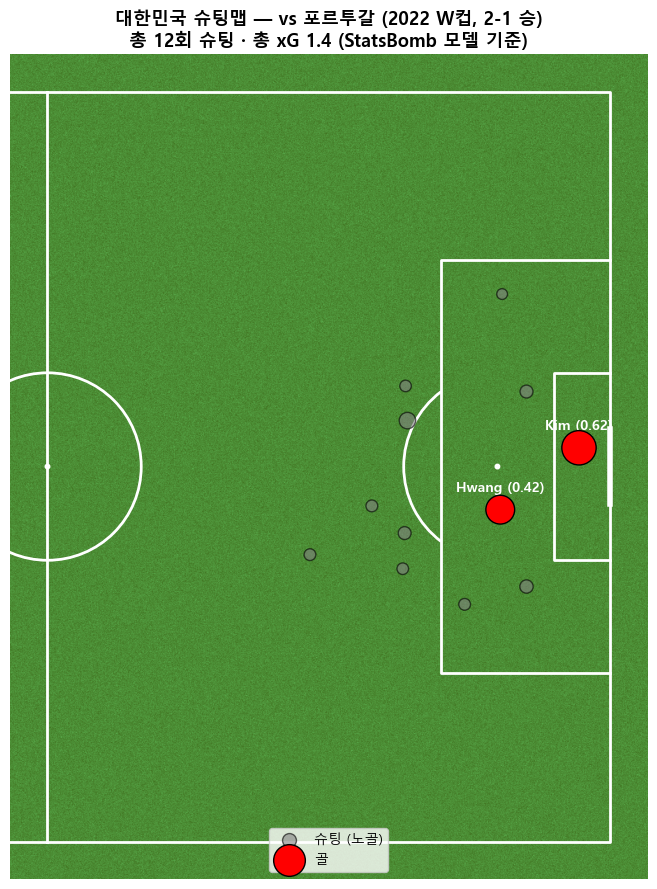

✅ xG 슈팅맵 완성!


In [10]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 좌표 분리 (이미 했으면 생략돼도 무방)
korea_shots['x'] = korea_shots['location'].apply(lambda loc: loc[0])
korea_shots['y'] = korea_shots['location'].apply(lambda loc: loc[1])

goals = korea_shots[korea_shots['shot_outcome'] == 'Goal']
no_goals = korea_shots[korea_shots['shot_outcome'] != 'Goal']

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white', half=True)
fig, ax = pitch.draw(figsize=(10, 9))

# 점 크기 = xG에 비례 (x900은 점이 보기 좋게 키우는 배율)
pitch.scatter(no_goals['x'], no_goals['y'], ax=ax,
              s=no_goals['shot_statsbomb_xg'] * 900 + 50,
              color='gray', alpha=0.6, edgecolors='black', label='슈팅 (노골)')
pitch.scatter(goals['x'], goals['y'], ax=ax,
              s=goals['shot_statsbomb_xg'] * 900 + 50,
              color='red', edgecolors='black', label='골', zorder=5)

# 골 선수 이름 + xG 표시
for _, row in goals.iterrows():
    name = row['player'].split()[-1]
    xg = round(row['shot_statsbomb_xg'], 2)
    ax.text(row['x'], row['y'] - 2, f"{name} ({xg})",
            color='white', fontsize=10, ha='center', fontweight='bold')

total_xg = round(korea_shots['shot_statsbomb_xg'].sum(), 2)
ax.set_title(f"대한민국 슈팅맵 — vs 포르투갈 (2022 W컵, 2-1 승)\n"
             f"총 {len(korea_shots)}회 슈팅 · 총 xG {total_xg} (StatsBomb 모델 기준)",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower center', fontsize=10)

plt.savefig('korea_portugal_xg_shotmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ xG 슈팅맵 완성!")